In [55]:
from src.utils import import_from_json, export_to_json

import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import numpy as np

from src.performance import compute_ISV
from model.validation import NTC2018HazardInput
from model.data_models.capacity import FrameCapacity
from src.hazard import NTC2018SeismicHazard

# Conversion factors
m_mm = 1000

Input Path

In [56]:
# Define the path to the output JSON file
PATH_CURVES: Path = Path('outputs/output.json')
SPECTRUM_PATH: Path = Path('inputs/spectrum.json')

# Output Paths
OUTPUT_ISV_PATH: Path = Path('outputs/isv.csv')
OUTPUT_CURVES_PATH: Path = Path('outputs/curves.json')

In [57]:
# Plotting options
ALPHA: float = 0.01

# **STEP 1**: Import capacity curves as is

In [58]:
# Import the curves from the JSON file
curves_dct = import_from_json(PATH_CURVES)

Plot the mechanisms as imported

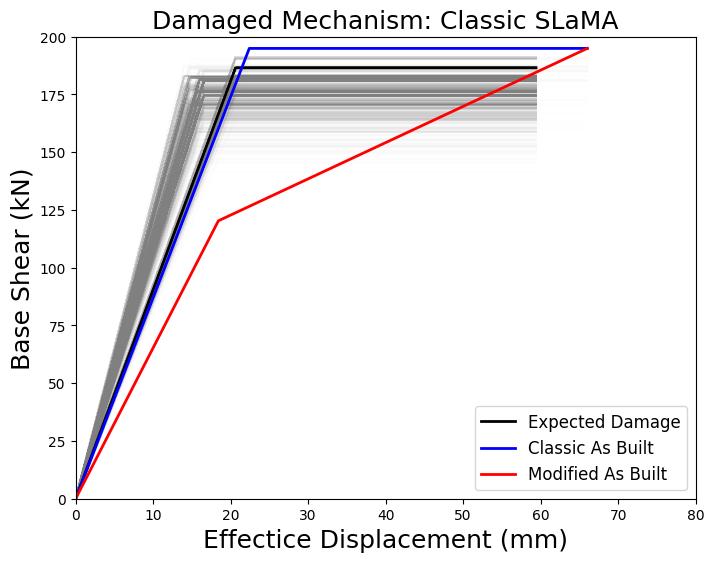

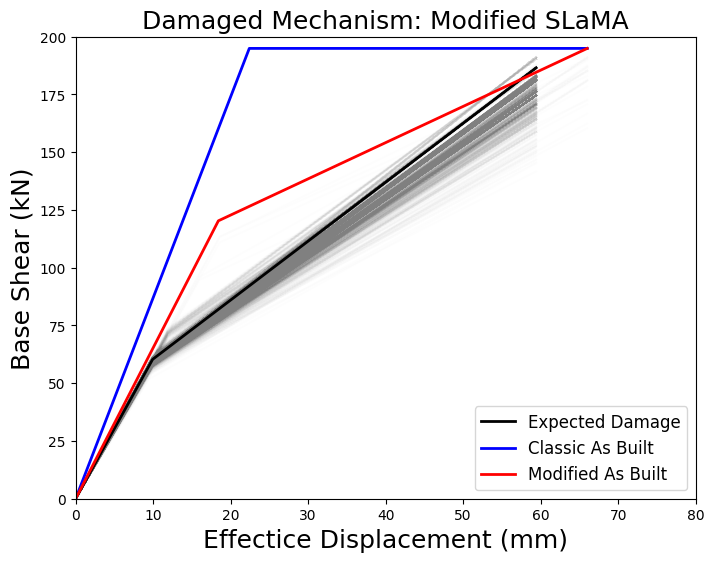

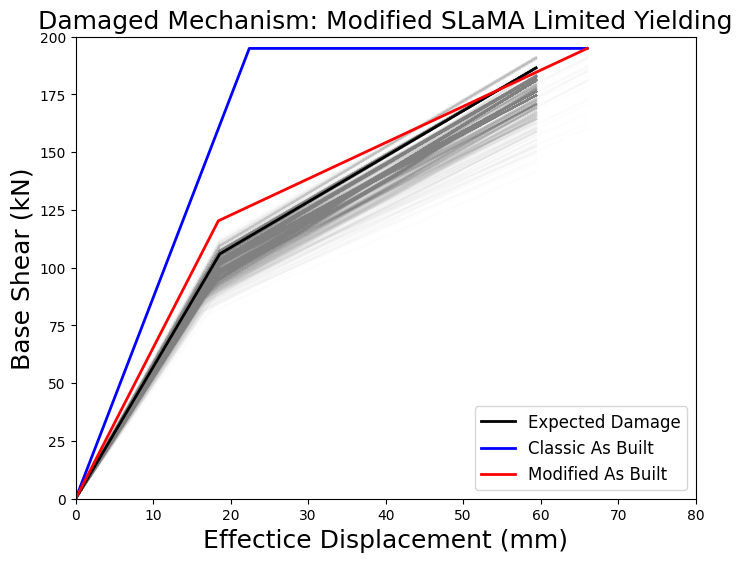

In [59]:

MECHANISMS = [
    'damaged_curves_classic',
    'damaged_curves_sub_stiff',
    'damaged_curves_modified'
]
NAMES = {
    'damaged_curves_classic': 'Classic SLaMA',
    'damaged_curves_sub_stiff': 'Modified SLaMA',
    'damaged_curves_modified': 'Modified SLaMA Limited Yielding'
}
for mechanism in MECHANISMS:
    plt.figure(figsize=(8, 6))
    # Plot all damaged_curves in gray with alpha 0.1
    for i, curve in enumerate(curves_dct[mechanism]):
        x, y = zip(*curve['curve'])
        if i == 0:
            continue
        plt.plot(np.array(x) * 1000, y, color='gray', alpha=ALPHA)

    x_expected, y_expected = zip(*curves_dct[mechanism][0]['curve'])
    # Plot expected curve in black with alpha 0.1
    plt.plot(np.array(x_expected) * 1000, y_expected, color='black', label='Expected Damage',linewidth=2)

    # Plot classic_SLaMA in a strong color
    x_classic, y_classic = zip(*curves_dct['classic_SLaMA']['curve'])
    plt.plot(np.array(x_classic) * 1000, y_classic, color='blue', label='Classic As Built', linewidth=2)

    # Plot stiffness_SLaMA in a strong color
    x_stiff, y_stiff = zip(*curves_dct['stiffness_SLaMA']['curve'])
    plt.plot(np.array(x_stiff) * 1000, y_stiff, color='red', label='Modified As Built', linewidth=2)

    plt.xlabel('Effectice Displacement (mm)', fontsize=18)
    plt.xlim(0, 80)
    plt.ylabel('Base Shear (kN)', fontsize=18)
    plt.ylim(0, 200)
    plt.title(f'Damaged Mechanism: {NAMES[mechanism]}', fontsize=18)
    plt.legend(fontsize=12)
    plt.show()

# **STEP 2**: Modify the curves to obtain a perfect bilinear

In [60]:
# Modify the stiffness_SLaMA curve to obtain a perfect bilinear
modified_curves_dct = {}
for mechanism in MECHANISMS[1:]:
    curves = []
    for curve in curves_dct[mechanism]:
        # First point is yielding
        disp_y, force_y = curve['curve'][1]
        # Last point is capacity
        disp_c, force_c = curve['curve'][-1]
        # Compute new yielding point
        yielding_stiffness = force_y / disp_y
        new_disp_y = force_c / yielding_stiffness

        curves.append(
            {
                'name': curve['name'],
                'mass': curve['mass'],
                'curve': [
                    [0, 0],  # Start at origin
                    [new_disp_y, force_c],  # Yield point
                    [disp_c, force_c],  # Capacity point
                ]
            }
        )
    modified_curves_dct[mechanism] = curves

# Reference curve
curve = curves_dct['stiffness_SLaMA']
# First point is yielding
disp_y, force_y = curve['curve'][1]
# Last point is capacity
disp_c, force_c = curve['curve'][-1]
# Compute new yielding point
yielding_stiffness = force_y / disp_y
new_disp_y = force_c / yielding_stiffness

curves_dct['stiffness_SLaMA_bil'] = {
    'name': curve['name'],
    'mass': curve['mass'],
    'curve': [
        [0, 0],  # Start at origin
        [new_disp_y, force_c],  # Yield point
        [disp_c, force_c],  # Capacity point
    ]
}

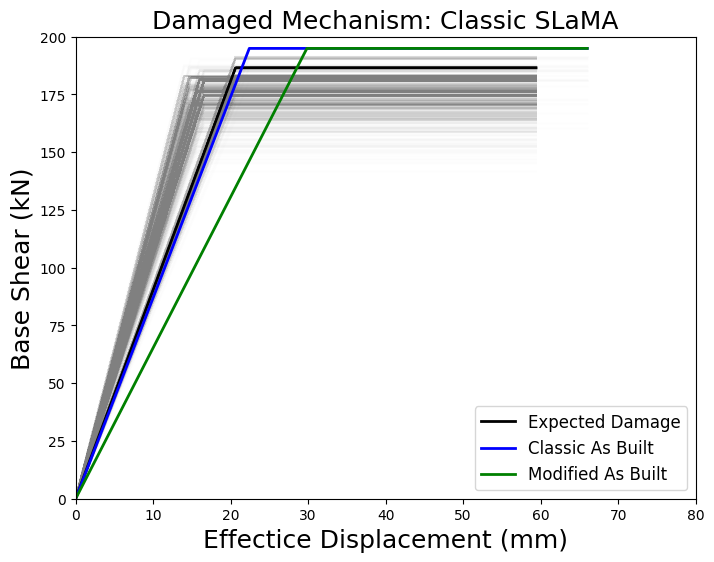

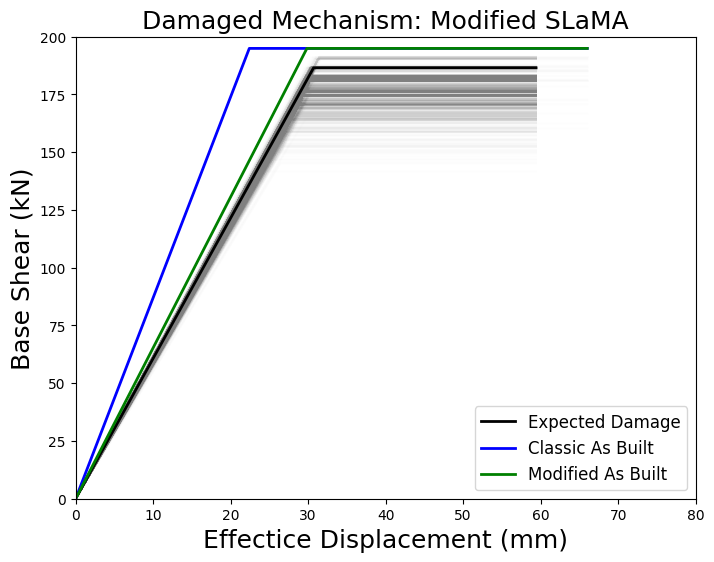

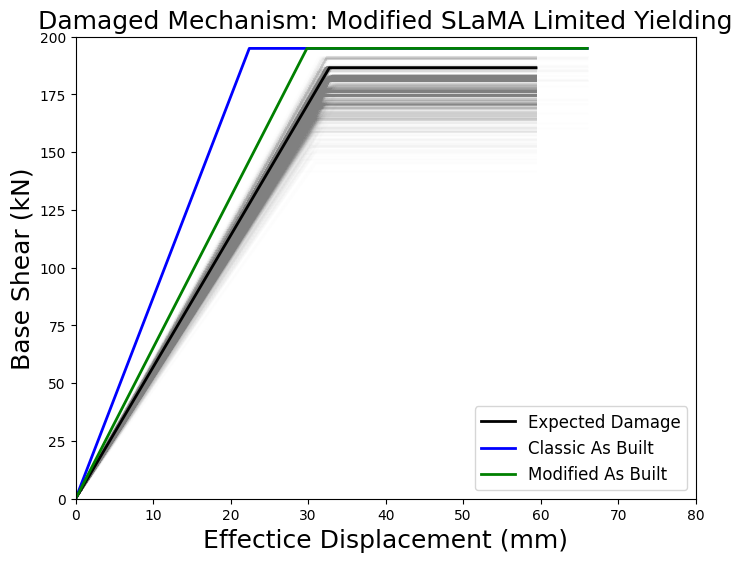

In [61]:
CURVES = {
    'damaged_curves_classic': curves_dct['damaged_curves_classic'],
    'damaged_curves_sub_stiff': modified_curves_dct['damaged_curves_sub_stiff'],
    'damaged_curves_modified': modified_curves_dct['damaged_curves_modified']
}
NAMES = {
    'damaged_curves_classic': 'Classic SLaMA',
    'damaged_curves_sub_stiff': 'Modified SLaMA',
    'damaged_curves_modified': 'Modified SLaMA Limited Yielding'
}
for mechanism, curves in CURVES.items():
    plt.figure(figsize=(8, 6))
    # Plot all damaged_curves in gray with alpha 0.1
    for i, curve in enumerate(curves):
        x, y = zip(*curve['curve'])
        if i == 0:
            continue
        plt.plot(np.array(x) * 1000, y, color='gray', alpha=ALPHA)

    x_expected, y_expected = zip(*curves[0]['curve'])
    # Plot expected curve in black with alpha 0.1
    plt.plot(np.array(x_expected) * 1000, y_expected, color='black', label='Expected Damage',linewidth=2)

    # Plot classic_SLaMA in a strong color
    x_classic, y_classic = zip(*curves_dct['classic_SLaMA']['curve'])
    plt.plot(np.array(x_classic) * 1000, y_classic, color='blue', label='Classic As Built', linewidth=2)

    # Plot stiffness_SLaMA in a strong color
    x_stiff, y_stiff = zip(*curves_dct['stiffness_SLaMA_bil']['curve'])
    plt.plot(np.array(x_stiff) * 1000, y_stiff, color='green', label='Modified As Built', linewidth=2)

    plt.xlabel('Effectice Displacement (mm)', fontsize=18)
    plt.xlim(0, 80)
    plt.ylabel('Base Shear (kN)', fontsize=18)
    plt.ylim(0, 200)
    plt.title(f'Damaged Mechanism: {NAMES[mechanism]}', fontsize=18)
    plt.legend(fontsize=12)
    plt.show()

# **STEP 3**: Compute performance

Import hazard

In [62]:
# Import hazard as spectrum
spectrum_dct = import_from_json(SPECTRUM_PATH)
validated_hazard = NTC2018HazardInput(**spectrum_dct)
spectrum = NTC2018SeismicHazard(validated_hazard)

spectrum_dct

{'ag': 0.265,
 'F0': 2.286,
 'Tc_star': 0.375,
 'Cu': 1,
 'Vn': 50,
 'soil_category': 'B',
 'topographic_category': 'T1'}

Compute capacity

In [63]:
# SAVE ISV_S IN a Dict 
isv_values = {}
isv_reference = {}

# Imported Curves
for kk, vv in curves_dct.items():
    if isinstance(vv, list):
        isv_s = []
        for curve in vv:
            x, y = zip(*curve['curve'])
            isv = compute_ISV(
                FrameCapacity(
                    name=curve['name'],
                    mass=curve['mass'],
                    disp=list(x),
                    base_shear=list(y)
                ),
                spectrum
            ) 
            isv_s.append(isv)
        isv_values[kk] = isv_s
    else:
        x, y = zip(*vv['curve'])
        isv = compute_ISV(
            FrameCapacity(
                name=vv['name'],
                mass=vv['mass'],
                disp=list(x),
                base_shear=list(y)
            ),
            spectrum
        ) 
        isv_reference[kk] = isv

# Modified Curves
for kk, vv in modified_curves_dct.items():
    isv_s = []
    for curve in vv:
        x, y = zip(*curve['curve'])
        isv = compute_ISV(
            FrameCapacity(
                name=curve['name'],
                mass=curve['mass'],
                disp=list(x),
                base_shear=list(y)
            ),
            spectrum
        ) 
        isv_s.append(isv)
    
    isv_values[kk + '_bil'] = isv_s

In [64]:
list(isv_values.keys())

['damaged_curves_classic',
 'damaged_curves_sub_stiff',
 'damaged_curves_modified',
 'damaged_curves_sub_stiff_bil',
 'damaged_curves_modified_bil']

damaged_curves_classic


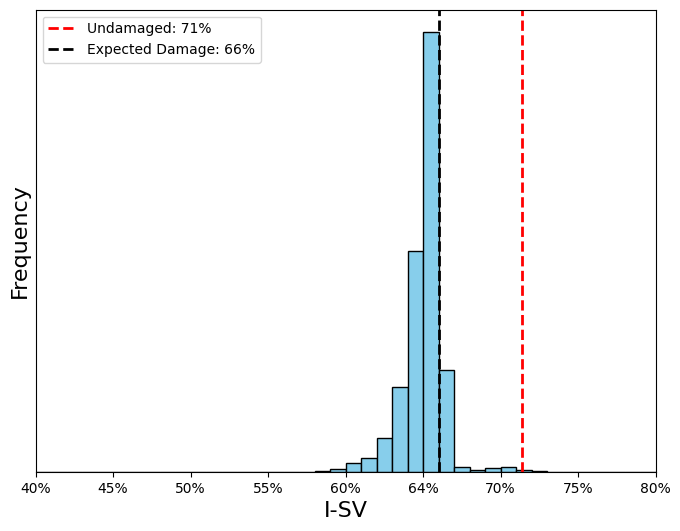

damaged_curves_sub_stiff


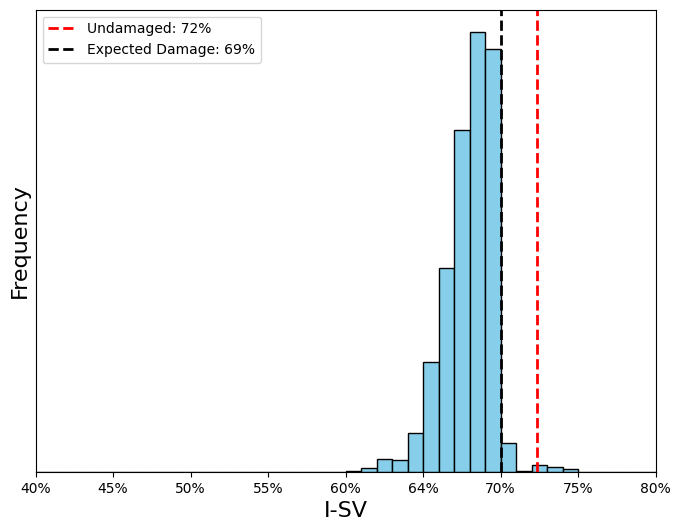

damaged_curves_modified


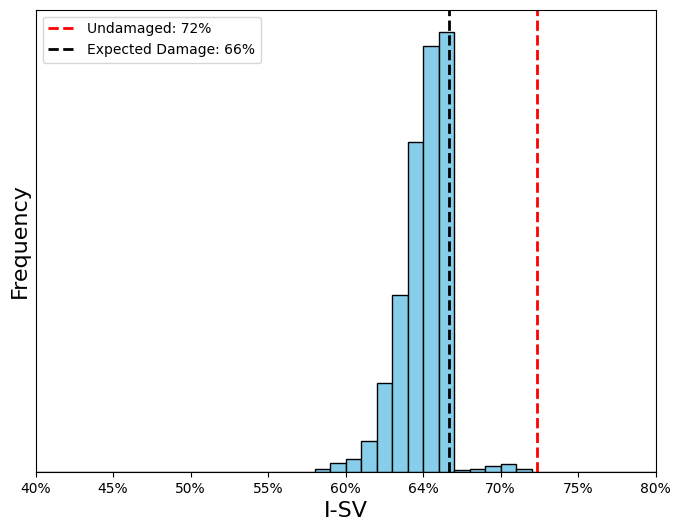

damaged_curves_sub_stiff_bil


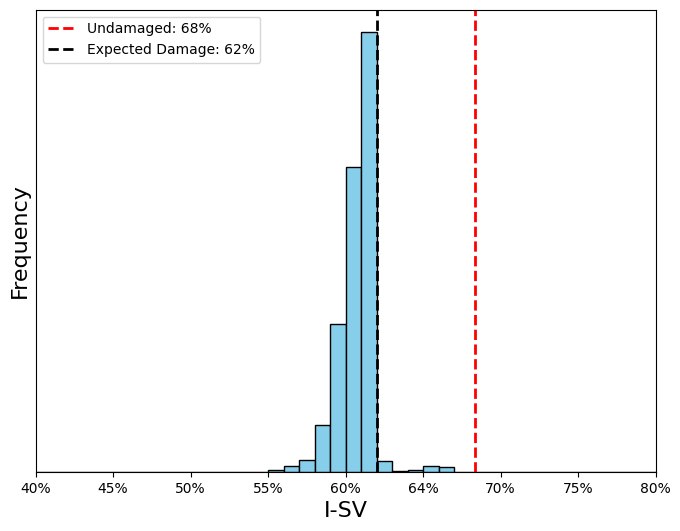

damaged_curves_modified_bil


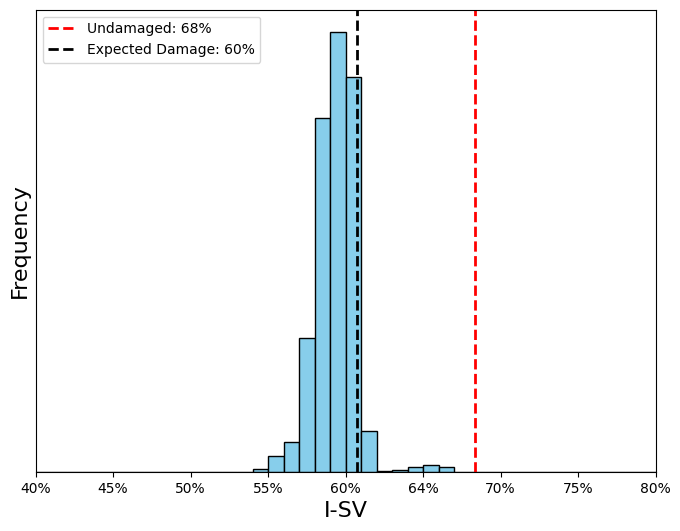

In [65]:
isv_classic = isv_reference['classic_SLaMA']
isv_modified = isv_reference['stiffness_SLaMA']
isv_bilinear = isv_reference['stiffness_SLaMA_bil']

# Plot ISV values\
reference_isv = {
    'damaged_curves_classic': 'classic_SLaMA', 
    'damaged_curves_sub_stiff': 'stiffness_SLaMA', 
    'damaged_curves_modified': 'stiffness_SLaMA', 
    'damaged_curves_sub_stiff_bil': 'stiffness_SLaMA_bil', 
    'damaged_curves_modified_bil': 'stiffness_SLaMA_bil'
}

for key, values in isv_values.items():
    plt.figure(figsize=(8, 6))
    bin_size = 0.01
    bins = np.arange(0, 1 + bin_size, bin_size)
    plt.hist(values, bins=bins, color='skyblue', edgecolor='black')
    print(key)
    # plt.axvline(isv_classic + bin_size / 2, color='blue', linestyle='--', linewidth=2, label=f'Classic SLaMA: {isv_classic:.0%}')
    isv = isv_reference[reference_isv[key]]
    plt.axvline(isv + bin_size / 2, color='red', linestyle='--', linewidth=2, label=f'Undamaged: {isv:.0%}')
    # plt.axvline(isv_bilinear + bin_size / 2, color='green', linestyle='--', linewidth=2, label=f'Modified SLaMA Bilinear: {isv_bilinear:.0%}')
    plt.axvline(values[0] + bin_size / 2, color='black', linestyle='--', linewidth=2, label=f'Expected Damage: {values[0]:.0%}')

    # plt.title(f'ISV Histogram: {key}', fontsize=16)
    plt.xlabel('I-SV', fontsize=16)
    plt.xlim(0.4, 0.8)
    plt.xticks(np.arange(0.4, 0.81, 0.05), [f"{int(x*100)}%" for x in np.arange(0.4, 0.81, 0.05)], fontsize=10)
    plt.ylabel('Frequency', fontsize=16)
    plt.yticks([])
    plt.legend()
    plt.show()


# **STEP 4**: Export Results

In [66]:
# Create dataframe
isv_df = pd.DataFrame(isv_values)

# Add reference values
for kk, vv in isv_reference.items():
    isv_df[kk] = np.full(len(isv_df), vv)

# Save the dataframe to a CSV file
isv_df.to_csv(OUTPUT_ISV_PATH, index=False)

In [67]:
# Create a copy of the curves dictionary
curves_dct_copy = curves_dct.copy()

# Add curves to the copy
for kk, vv in modified_curves_dct.items():
    curves_dct_copy[kk + '_bil'] = vv

# Export to json
export_to_json(OUTPUT_CURVES_PATH, curves_dct_copy)